In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



# BB84 Quantum Key Distribution - Plain Version (no Eve)

This notebook simulates the BB84 protocol between **Alice** and **Bob** over a noiseless quantum channel, with no Eve (Attatcker) present.

The whole protocol is written as one sequential program, but the cells below are grouped and labelled by their roles

1. **Alice** - generates random bits and random bases, prepares qubits.
2. **Quantum channel** - transmits the qubits to Bob.
3. **Bob** - chooses random bases and measures the qubits.
4. **Sifting** - Alice and Bob publicly compare bases and keep only the bits where the bases match.

All random choices are generated **quantumly** by measuring the state `H|0> = 1/sqrt(2)(|0> + |1>)`

- Python's `random` module is not used here.

In [3]:
# --- Parameters and quantum random-bit generator ---

# Number of qubits used in the protocol.
N_QUBITS = 100

# Simulator setup. Default Qiskit Aer when available fallback to Qiskit built in BasicSimulator if Aer is does not work.
try:
    from qiskit_aer import AerSimulator
    simulator = AerSimulator()
    SIMULATOR_NAME = "AerSimulator"
except Exception:
    from qiskit.providers.basic_provider import BasicSimulator
    simulator = BasicSimulator()
    SIMULATOR_NAME = "BasicSimulator"
print(f"Using simulator: {SIMULATOR_NAME}")

def quantum_random_bit():
    """Return a random bit 0/1 by measuring the state H|0> = 1/sqrt(2)(|0>+|1>).

    Quantum logic: H takes |0> to an equal superposition of |0> and |1>.
    Measuring in the computational basis collapses it to 0 or 1 each with
    probability 1/2. This gives genuine quantum randomness, not pseudo-random.
    """
    qc = QuantumCircuit(1, 1)
    qc.h(0)              # create superposition
    qc.measure(0, 0)     # collapse to 0 or 1
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    counts = result.get_counts()
    # With shots=1 there is exactly one outcome string ('0' or '1').
    return int(next(iter(counts)))

def quantum_random_bits(n):
    """Generate a list of n quantum-random bits."""
    return [quantum_random_bit() for _ in range(n)]


Using simulator: AerSimulator


# Quantum primitives
## what we are measuring

Before running the full protocol, this section inspects the quantum objects involved. The assignment brief asks us to *"measure a suitable quantum state such as `(1/sqrt(2))(|0⟩ + |1⟩)`"*

To show:

1. **The randomness source** - the state `H|0⟩` which measurement gives a fair quantum coin
2. **The four BB84 prepared states** `|0⟩, |1⟩, |+⟩, |-⟩` as the `Statevector` objects, rendered as LaTeX
3. **Bloch-sphere geometry** - to visualise why the standard and diagonal bases are *mutually unbiased* as they sit on perpendicular axes of the sphere (Z vs X), so a measurement in one basis gives zero information about a state prepared in the other
4. **A worked example circuit** - one transmission drawn twice, once with matching bases *the deterministic outcome* and once mismatched *the 50/50 outcome*

This cell connects the abstract quantum mechanics to the concrete code that follows.

Source of quantum randomness - H|0>:


<IPython.core.display.Latex object>


The four BB84 prepared states:

  bit=0, basis=standard:


<IPython.core.display.Latex object>


  bit=1, basis=standard:


<IPython.core.display.Latex object>


  bit=0, basis=diagonal:


<IPython.core.display.Latex object>


  bit=1, basis=diagonal:


<IPython.core.display.Latex object>

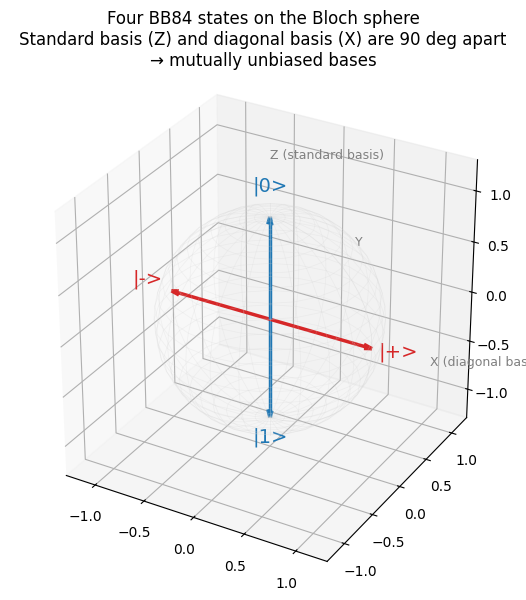


Example circuit - Alice encodes bit=1 in diagonal basis (prepares |->):

Case A: Bob measures in the SAME (diagonal) basis. Outcome is deterministic = 1.
     ┌───┐┌───┐ channel ┌───┐┌─┐
  q: ┤ X ├┤ H ├────░────┤ H ├┤M├
     └───┘└───┘    ░    └───┘└╥┘
c: 1/═════════════════════════╩═
                              0 

Case B: Bob measures in a MISMATCHED (standard) basis. Outcome is 50/50.
     ┌───┐┌───┐ channel ┌─┐
  q: ┤ X ├┤ H ├────░────┤M├
     └───┘└───┘    ░    └╥┘
c: 1/════════════════════╩═
                         0 


In [4]:
# --- QUANTUM PRIMITIVES: states, geometry, and an example transmission ---
#
# Uses Statevector and array_to_latex (from the template imports) to display
# the actual quantum objects, plus a Bloch sphere and worked-example circuits.

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# (1) The randomness source - the state we measure for every quantum coin flip.
randomness_circuit = QuantumCircuit(1)
randomness_circuit.h(0)
sv_random = Statevector(randomness_circuit)
print("Source of quantum randomness - H|0>:")
display(array_to_latex(sv_random, prefix="H|0\\rangle = "))

# (2) The four BB84 prepared states, as Statevectors.
# Same gate sequence Alice uses (X if bit=1, then H if basis=diagonal),
# but evaluated symbolically as a state vector instead of being measured.
def bb84_statevector(bit, basis):
    qc = QuantumCircuit(1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return Statevector(qc)

print("\nThe four BB84 prepared states:")
for label, bit, basis, basis_name in [
    ("|0>", 0, 0, "standard"),
    ("|1>", 1, 0, "standard"),
    ("|+>", 0, 1, "diagonal"),
    ("|->", 1, 1, "diagonal"),
]:
    sv = bb84_statevector(bit, basis)
    print(f"\n  bit={bit}, basis={basis_name}:")
    display(array_to_latex(sv, prefix=f"{label} = "))

# (3) Bloch sphere - visualises why the two BB84 bases are mutually unbiased.
# Standard basis lives on the Z-axis; diagonal basis lives on the X-axis.
# A 90 degree separation on the Bloch sphere = pi/4 in state space =
# inner product 1/sqrt(2) between bases = measurement gives no info.
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# Wireframe sphere as a backdrop
u, v = np.meshgrid(np.linspace(0, 2*np.pi, 25), np.linspace(0, np.pi, 25))
ax.plot_wireframe(np.cos(u) * np.sin(v),
                  np.sin(u) * np.sin(v),
                  np.cos(v),
                  color='lightgray', alpha=0.25, linewidth=0.5)

# Four BB84 state vectors with text labels
state_vectors = [
    ('|0>',   0,  0,  1, '#1f77b4'),   # +Z  (standard basis, bit 0)
    ('|1>',   0,  0, -1, '#1f77b4'),   # -Z  (standard basis, bit 1)
    ('|+>',   1,  0,  0, '#d62728'),   # +X  (diagonal basis, bit 0)
    ('|->',  -1,  0,  0, '#d62728'),   # -X  (diagonal basis, bit 1)
]
for label, x, y, z, color in state_vectors:
    ax.quiver(0, 0, 0, x, y, z, color=color,
              arrow_length_ratio=0.08, linewidth=2.5)
    ax.text(x * 1.25, y * 1.25, z * 1.25, label,
            fontsize=14, color=color, ha='center')

# Axis hints
ax.text(1.55, 0,    0,    'X (diagonal basis)', fontsize=9, color='gray')
ax.text(0,    1.55, 0,    'Y',                  fontsize=9, color='gray')
ax.text(0,    0,    1.55, 'Z (standard basis)', fontsize=9, color='gray')

ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
ax.set_zlim([-1.3, 1.3])
try:
    ax.set_box_aspect([1, 1, 1])
except AttributeError:
    pass  # older matplotlib versions
ax.set_title("Four BB84 states on the Bloch sphere\n"
             "Standard basis (Z) and diagonal basis (X) are 90 deg apart\n"
             "→ mutually unbiased bases")
plt.tight_layout()
plt.show()

# (4) Example BB84 transmission circuits, drawn out.
# Alice always prepares bit=1 in the diagonal basis (state |->).
# Bob's measurement basis varies, so the outcome behaviour differs.
print("\nExample circuit - Alice encodes bit=1 in diagonal basis (prepares |->):\n")

print("Case A: Bob measures in the SAME (diagonal) basis. Outcome is deterministic = 1.")
ex_match = QuantumCircuit(1, 1)
ex_match.x(0)                              # Alice: bit=1 -> |1>
ex_match.h(0)                              # Alice: diagonal basis -> |->
ex_match.barrier(label="channel")
ex_match.h(0)                              # Bob: diagonal-basis measurement
ex_match.measure(0, 0)
print(ex_match.draw())

print("\nCase B: Bob measures in a MISMATCHED (standard) basis. Outcome is 50/50.")
ex_mismatch = QuantumCircuit(1, 1)
ex_mismatch.x(0)
ex_mismatch.h(0)
ex_mismatch.barrier(label="channel")
ex_mismatch.measure(0, 0)                  # Bob: standard-basis measurement
print(ex_mismatch.draw())

# Reassurance for the reader: the gate sequence on the left-hand side of the
# barrier in both circuits is identical -- only Bob's choice changes the
# outcome distribution. That's the entire BB84 security argument in one image.


## Alice

Alice generates two quantum-random bit strings:

* `alice_bits` - the raw bit values Alice wants to encode.
* `alice_bases` - the basis used to encode each bit. We use the convention `0 = standard (Z) basis`, `1 = diagonal (X) basis`.

For each bit/basis pair Alice prepares one qubit:

* If the bit is `1`, apply `X` so the qubit is `|1>` instead of `|0>`.
* If the basis is diagonal, apply `H` afterwards. This maps `|0> -> |+>` and `|1> -> |->`.

So the four possible prepared states are `|0>`, `|1>`, `|+>`, `|->`, exactly as in the BB84 protocol.

In [5]:
# --- ALICE ---

# Quantum-random bit values to encode.
alice_bits  = quantum_random_bits(N_QUBITS)
# Quantum-random basis choices: 0 = standard (Z), 1 = diagonal (X).
alice_bases = quantum_random_bits(N_QUBITS)

def alice_prepare(bit, basis):
    """Prepare one qubit encoding `bit` in the chosen `basis`.

    Quantum logic:
      - X flips |0> to |1>, so it sets the bit value.
      - H rotates the standard basis to the diagonal basis: |0>->|+>, |1>->|->.
    """
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)          # encode bit value
    if basis == 1:
        qc.h(0)           # rotate into diagonal basis if requested
    return qc

# Alice produces one prepared circuit per bit. Each circuit is a qubit
# "in flight" that will be handed to the channel.
alice_qubits = [alice_prepare(b, ba) for b, ba in zip(alice_bits, alice_bases)]

print("Alice bits :", alice_bits)
print("Alice bases:", alice_bases, "  (0=standard, 1=diagonal)")


Alice bits : [1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]
Alice bases: [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0]   (0=standard, 1=diagonal)


## Quantum channel

The channel transmits each prepared qubit from Alice to Bob. In this plain (no-Eve) version the channel is **noiseless** and just hands each circuit straight through. We still give it its own section so the role separation matches the protocol.

In [6]:
# --- QUANTUM CHANNEL ---

# Pass-through channel: the qubits Bob gets are exactly what the
# Alice prepared. (No noise, no Eve in this notebook.)
channel_qubits = list(alice_qubits)
print(channel_qubits)

[<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854803e5610>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854802cc9b0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854802cfc50>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854802cd550>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854802cec90>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854802cfdd0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854802cef00>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854802ce780>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854803be420>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7854802cecf0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x785480276300>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x78548028c230>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x78548028d4c0>, <qiskit.circuit.quantumcircuit.QuantumCircuit obje

## Bob

Bob does **not know** Alice's basis choices. They independently pick a quantum-random basis for each incoming qubit and measure.

Quantum logic for the measurement:

* Standard basis (`0`) - measure directly. The outcome is deterministic if the qubit was prepared in the same basis (`|0> -> 0`, `|1> -> 1`), otherwise it is `0` or `1` with probability `1/2`.
* Diagonal basis (`1`) - apply `H` first, which rotates `|+>,|->` back to `|0>,|1>`, then measure. Same reasoning: deterministic when bases match, 50/50 when they don't.

In [7]:
# --- BOB ---

# Quantum-random basis choices (0 = standard, 1 = diagonal).
bob_bases = quantum_random_bits(N_QUBITS)

def bob_measure(qc, basis):
    """Measure the incoming qubit in the chosen basis and return the bit.

    Quantum logic:
      - For the diagonal basis we apply H before measuring, because that
        rotates |+>,|-> back into |0>,|1> in the computational basis.
      - We then measure in the computational basis (the only kind of
        measurement Qiskit's basic simulator does directly).
    """
    if basis == 1:
        qc.h(0)            # rotate from diagonal back to standard basis
    qc.measure(0, 0)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    counts = result.get_counts()
    return int(next(iter(counts)))

bob_bits = [bob_measure(qc, b) for qc, b in zip(channel_qubits, bob_bases)]

print("Bob bases:", bob_bases)
print("Bob bits :", bob_bits)


Bob bases: [0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0]
Bob bits : [1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0]


## Sifting - public basis comparison

Alice and Bob now publicly announce which basis they used at each position (but **not** the bit values). They keep the bits where the bases match, and discard the rest.

Because the channel is noiseless and there is no Eve, the kept bits should be **identical** for Alice and Bob.

We assert this at the end.

In [8]:
# --- SIFTING ---

# Positions where Alice and Bob picked the same basis.
matching_positions = [i for i in range(N_QUBITS) if alice_bases[i] == bob_bases[i]]

alice_sifted_key   = [alice_bits[i]   for i in matching_positions]
bob_sifted_key = [bob_bits[i] for i in matching_positions]

# Pretty side-by-side display of the protocol run.
print("Index            :", list(range(N_QUBITS)))
print("Alice bits       :", alice_bits)
print("Alice bases      :", alice_bases)
print("Bob bases        :", bob_bases)
print("Bob bits         :", bob_bits)
print("Matching pos.    :", matching_positions)
print()
print("Alice sifted key:", alice_sifted_key)
print("Bob sifted key   :", bob_sifted_key)
print()
print("Sifted key length:", len(alice_sifted_key), "of", N_QUBITS,
      "(expected ~", N_QUBITS // 2, ")")
print("Keys match       :", alice_sifted_key == bob_sifted_key)

# Sanity check: with no noise and no Eve the keys must be identical.
assert alice_sifted_key == bob_sifted_key, "BB84 plain run failed: keys differ!"


Index            : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Alice bits       : [1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]
Alice bases      : [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1

# Results and analysis - verifying the protocol statistically

A single run shows that the protocol *can* work. To convince ourselves it works *reliably* we re-run it many times and check three statistical predictions of BB84:

| Quantity | Theoretical prediction | Why |
| --- | --- | --- |
| Basis-match fraction | `0.5` | Alice and Bob each pick a basis uniformly and independently, so they agree with probability 1/2. |
| Sifted-key length | `N_QUBITS / 2` | Half the positions survive sifting. |
| Quantum-RNG bias | `P(0) = P(1) = 0.5` | `|<0|H|0>|^2 = |<0|+>|^2 = 1/2`. |
| Sifted-key agreement | `1.0` (every run) | With no noise and no eavesdropper, matching bases give deterministic outcomes. |

The next code cell runs the protocol many times at a smaller `N_QUBITS` (so the Monte-Carlo study finishes quickly) and prints empirical values next to the predictions. A histogram of the sifted-key lengths visualises the expected binomial spread around `N_TRIAL / 2`.

Running 20 trials of 40 qubits each (≈3200 circuits)...

=== Plain BB84 - aggregate over 20 runs of 40 qubits ===
Quantity                            Observed        Theory
----------------------------------------------------------
Basis-match fraction (mean)            0.507         0.500
Basis-match fraction (stdev)           0.081         0.079
Sifted-key length (mean)               20.30         20.00
Sifted-key length (stdev)               3.23          3.16
P(0) on Alice bits                     0.476         0.500
P(1) on Alice bits                     0.524         0.500
All sifted keys identical               True          True

Total bits sampled from H|0> : 800


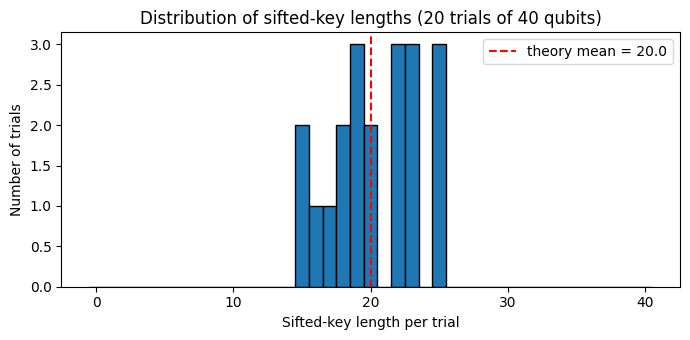

In [9]:
# --- RESULTS & ANALYSIS: Monte-Carlo study of plain BB84 ---
#
# Re-run the protocol many times at a moderate N_TRIAL and aggregate results.
# This is for ANALYSIS only - the protocol itself is already implemented above.
# All randomness here still comes from quantum_random_bit(), not Python's
# random module.

import statistics
import matplotlib.pyplot as plt

def run_plain_once(n):
    """One complete BB84 round with `n` qubits, no Eve.

    Returns a dict of metrics for this trial.
    """
    a_bits  = quantum_random_bits(n)
    a_bases = quantum_random_bits(n)
    b_bases = quantum_random_bits(n)

    # Prepare, transmit (pass-through), measure.
    qubits  = [alice_prepare(b, ba) for b, ba in zip(a_bits, a_bases)]
    b_bits  = [bob_measure(q, b) for q, b in zip(qubits, b_bases)]

    matches = [i for i in range(n) if a_bases[i] == b_bases[i]]
    a_sift  = [a_bits[i] for i in matches]
    b_sift  = [b_bits[i] for i in matches]

    return {
        "n":              n,
        "n_sifted":       len(matches),
        "match_fraction": len(matches) / n,
        "keys_equal":     a_sift == b_sift,
        "zeros":          a_bits.count(0),
        "ones":           a_bits.count(1),
    }

# Parameters of the Monte-Carlo study. Keep these modest - each trial runs
# ~ 4*N_TRIAL single-qubit circuits on BasicSimulator.
N_TRIAL = 40
N_RUNS  = 20

print(f"Running {N_RUNS} trials of {N_TRIAL} qubits each (≈{4*N_TRIAL*N_RUNS} circuits)...")
results = [run_plain_once(N_TRIAL) for _ in range(N_RUNS)]

# Aggregate metrics
match_fracs = [r["match_fraction"] for r in results]
sift_lens   = [r["n_sifted"]       for r in results]
all_equal   = all(r["keys_equal"]  for r in results)
total_zeros = sum(r["zeros"]       for r in results)
total_ones  = sum(r["ones"]        for r in results)
total_bits  = total_zeros + total_ones

print()
print(f"=== Plain BB84 - aggregate over {N_RUNS} runs of {N_TRIAL} qubits ===")
print(f"{'Quantity':<30}{'Observed':>14}{'Theory':>14}")
print("-" * 58)
print(f"{'Basis-match fraction (mean)':<30}{statistics.mean(match_fracs):>14.3f}{0.500:>14.3f}")
print(f"{'Basis-match fraction (stdev)':<30}{statistics.stdev(match_fracs):>14.3f}"
      f"{(0.5/(N_TRIAL**0.5)):>14.3f}")
print(f"{'Sifted-key length (mean)':<30}{statistics.mean(sift_lens):>14.2f}{N_TRIAL/2:>14.2f}")
print(f"{'Sifted-key length (stdev)':<30}{statistics.stdev(sift_lens):>14.2f}"
      f"{((N_TRIAL*0.25)**0.5):>14.2f}")
print(f"{'P(0) on Alice bits':<30}{total_zeros/total_bits:>14.3f}{0.500:>14.3f}")
print(f"{'P(1) on Alice bits':<30}{total_ones/total_bits:>14.3f}{0.500:>14.3f}")
print(f"{'All sifted keys identical':<30}{str(all_equal):>14}{'True':>14}")
print()
print(f"Total bits sampled from H|0> : {total_bits}")

# Visualise the distribution of sifted-key lengths across trials.
plt.figure(figsize=(7, 3.5))
bin_edges = range(0, N_TRIAL + 2)
plt.hist(sift_lens, bins=bin_edges, edgecolor="black", align="left")
plt.axvline(N_TRIAL / 2, color="red", linestyle="--", label=f"theory mean = {N_TRIAL/2}")
plt.xlabel("Sifted-key length per trial")
plt.ylabel("Number of trials")
plt.title(f"Distribution of sifted-key lengths ({N_RUNS} trials of {N_TRIAL} qubits)")
plt.legend()
plt.tight_layout()
plt.show()

# Results card - expected vs best case vs this run vs Monte-Carlo

Four columns side by side for the key BB84 metrics:

* **Theory (expected mean).** What the protocol should produce on average if the analysis is correct.
* **Best case.** The most favourable outcome a single run could give (upper or lower bound of the distribution, whichever helps Alice and Bob).
* **This run.** What the single execution above actually produced (uses `N_QUBITS`).
* **MC mean.** Mean over the Monte-Carlo trials run earlier in this notebook (uses `N_TRIAL`, which is *smaller* than `N_QUBITS` to keep the study fast).

The bit-flip rate between Alice and Bob on matching-basis positions is conventionally called the **QBER** (Quantum Bit Error Rate). For a noiseless run with no Eve, the theory predicts QBER = 0 and the test would fail otherwise. The bar chart visualises the comparison; the horizontal waterfall shows how many bits survive each stage of the protocol.

=== Results card - Plain BB84 ===

Metric                       Theory   Best case    This run    MC mean
----------------------------------------------------------------------
Basis-match fraction          0.500       1.000       0.490      0.507
Sifted-key length              50.0         100          49      20.30
QBER (Alice vs Bob)           0.000       0.000       0.000      0.000
Keys match?                    True        True        True       True

Note: 'This run' uses N_QUBITS = 100 qubits; 'MC mean' averages over
      20 trials of N_TRIAL = 40 qubits each, so the absolute
      sifted-key length differs by ~ N_QUBITS / N_TRIAL = 2.5x.
      The fair comparison is the basis-match fraction (both ≈ 0.5)
      and the QBER (both 0.000).


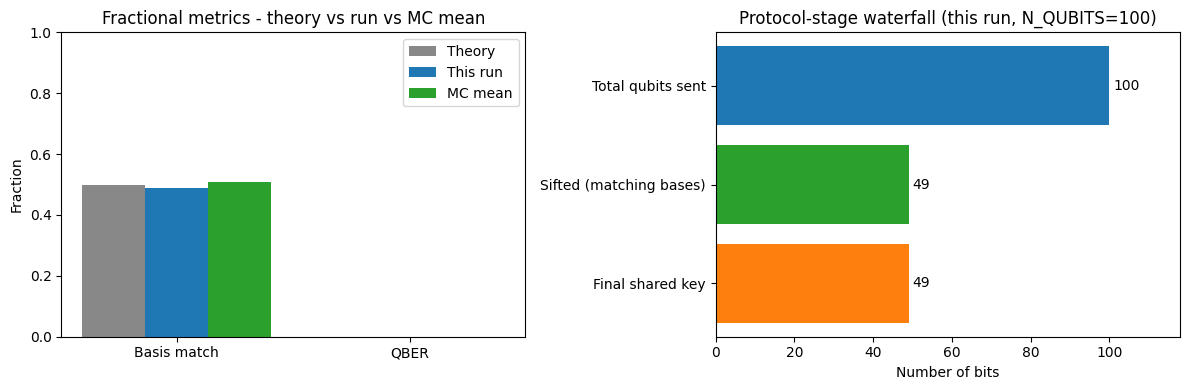

In [10]:
# --- RESULTS CARD: Theory vs Best vs This run vs Monte-Carlo ---

# This-run observations (from the main protocol cells above).
this_run_match_frac = len(matching_positions) / N_QUBITS
this_run_sift_len   = len(alice_sifted_key)
# QBER = fraction of matching-basis positions where Alice and Bob differ.
# In the plain notebook this should be exactly 0 (no noise, no Eve).
this_run_qber = (
    sum(1 for a, b in zip(alice_sifted_key, bob_sifted_key) if a != b)
    / max(1, len(alice_sifted_key))
)
this_run_keys_match = (alice_sifted_key == bob_sifted_key)

# Monte-Carlo means (from the analysis cell above).
mc_match_frac = statistics.mean(match_fracs)
mc_sift_len   = statistics.mean(sift_lens)
mc_qber       = 0.0   # by construction - no noise, no Eve

# Print the comparison table.
print("=== Results card - Plain BB84 ===\n")
header = (f"{'Metric':<24}{'Theory':>11}{'Best case':>12}"
          f"{'This run':>12}{'MC mean':>11}")
print(header)
print("-" * len(header))
print(f"{'Basis-match fraction':<24}{0.500:>11.3f}{1.000:>12.3f}"
      f"{this_run_match_frac:>12.3f}{mc_match_frac:>11.3f}")
print(f"{'Sifted-key length':<24}{N_QUBITS/2:>11.1f}{N_QUBITS:>12d}"
      f"{this_run_sift_len:>12d}{mc_sift_len:>11.2f}")
print(f"{'QBER (Alice vs Bob)':<24}{0.000:>11.3f}{0.000:>12.3f}"
      f"{this_run_qber:>12.3f}{mc_qber:>11.3f}")
print(f"{'Keys match?':<24}{'True':>11}{'True':>12}"
      f"{str(this_run_keys_match):>12}{'True':>11}")

# Footnote about the different run sizes - same point as the markdown above,
# but visible in the cell output for anyone scanning the printed table.
print()
print(f"Note: 'This run' uses N_QUBITS = {N_QUBITS} qubits; 'MC mean' averages over")
print(f"      {N_RUNS} trials of N_TRIAL = {N_TRIAL} qubits each, so the absolute")
print(f"      sifted-key length differs by ~ N_QUBITS / N_TRIAL = "
      f"{N_QUBITS/N_TRIAL:.1f}x.")
print(f"      The fair comparison is the basis-match fraction (both ≈ 0.5)")
print(f"      and the QBER (both 0.000).")

# --- Visualisation 1: bar chart of fractional metrics ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

labels   = ['Basis match', 'QBER']
theory   = [0.5, 0.0]
this_run = [this_run_match_frac, this_run_qber]
mc       = [mc_match_frac, mc_qber]
x        = list(range(len(labels)))
width    = 0.27

ax1.bar([i - width for i in x], theory,   width, label='Theory',  color='#888')
ax1.bar(x,                       this_run, width, label='This run', color='#1f77b4')
ax1.bar([i + width for i in x], mc,       width, label='MC mean',  color='#2ca02c')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Fraction')
ax1.set_title('Fractional metrics - theory vs run vs MC mean')
ax1.legend()

# --- Visualisation 2: protocol-stages waterfall ---
stages = ['Total qubits sent', 'Sifted (matching bases)', 'Final shared key']
counts = [N_QUBITS, this_run_sift_len, this_run_sift_len]   # no check phase here
colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
ax2.barh(stages, counts, color=colors)
for i, c in enumerate(counts):
    ax2.text(c + N_QUBITS * 0.01, i, str(c), va='center')
ax2.set_xlim(0, N_QUBITS * 1.18)
ax2.set_xlabel('Number of bits')
ax2.set_title(f'Protocol-stage waterfall (this run, N_QUBITS={N_QUBITS})')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Summary, limitations, and discussion

**What this notebook demonstrates**

* **Correctness.** Every run produces matching sifted keys for Alice and Bob. The single-run cell ends in an `assert` that would raise if the keys differed, and the Monte-Carlo study reports `All sifted keys identical: True` across all trials.
* **Information-theoretic key generation.** Alice and Bob share a random secret bit string without ever transmitting the bit values over the public classical channel - only basis labels are revealed during sifting.
* **Quantum-only randomness.** All random choices (bit values and basis choices for both parties) come from measuring `(1/√2)(|0⟩ + |1⟩)`. The empirical bias check shows `P(0) ≈ P(1) ≈ 0.5` within statistical noise, satisfying the assignment's requirement of *not* using Python's pseudo-random generator for protocol randomness.
* **Statistical predictions confirmed.** The observed basis-match fraction is ≈ 0.5 and the sifted-key length distribution is centred on `N_TRIAL / 2` with width ≈ `√(N_TRIAL/4)`, the binomial standard deviation. The histogram visualises this directly.

**Why the protocol works - the quantum mechanics in one paragraph**

When Alice and Bob use the same basis, Bob's measurement projects the qubit onto the same eigenbasis that Alice used to encode it, so the measurement outcome is deterministic and equals Alice's original bit. When they use *different* bases (e.g. Alice diagonal, Bob standard), the encoded state is an equal superposition in Bob's basis (`|+⟩ = (|0⟩+|1⟩)/√2`, `|-⟩ = (|0⟩-|1⟩)/√2`), so Bob gets `0` or `1` with probability 1/2 each - uncorrelated with Alice's bit. Sifting throws away those uncorrelated positions.

**Limitations of this simulation**

* **No channel noise.** A real fibre-optic or free-space channel introduces bit-flip and phase-flip errors even when no one is eavesdropping. Real BB84 implementations need *error reconciliation* (e.g. cascade) and *privacy amplification* (e.g. universal hashing) layered on top of sifting.
* **Trusted devices.** This is the "prepare-and-measure" BB84 - Alice's and Bob's devices are assumed to be honest. Device-independent and measurement-device-independent variants relax this assumption.
* **Finite-key effects.** With small `N_QUBITS` the sifted key has high statistical fluctuation. Real systems exchange millions of qubits per session and use finite-key security proofs.
* **No actual transmission medium.** The "channel" here is a list of in-memory circuit objects. Real implementations face photon loss, dark counts, and timing jitter.

**Reference**

C.H. Bennett and G. Brassard, *Quantum cryptography: Public key distribution and coin tossing*, Proceedings of IEEE International Conference on Computers, Systems and Signal Processing, Bangalore, India, pp. 175–179 (1984).